# Notebook 1: Getting Started with Machine Learning – Your First Model
**Part 1/30 – ML Mastery Series for Python Experts**

## What is Machine Learning?

Machine Learning (ML) represents a paradigm shift in how we solve problems with code. Let's break down the fundamental difference:

### Traditional Programming vs. Machine Learning

| Traditional Programming | Machine Learning |
|------------------------|------------------|
| You write explicit rules | You provide data and desired outputs |
| Rules → Data → Answers | Data + Answers → Rules (Model) |
| Example: `if petal_length > 2.5: return 'versicolor'` | Example: Learn the boundary automatically from 150 labeled flowers |

In ML, the algorithm discovers patterns in training data and encodes them into a model that can generalize to new, unseen data.

### The Three Main Types of Machine Learning

**1. Supervised Learning** 🎯
- You have labeled training data (input → known output)
- The algorithm learns a mapping function from inputs to outputs
- *Real-world example:* Email spam detection (thousands of emails marked as "spam" or "not spam" teach the model to classify new messages)

**2. Unsupervised Learning** 🔍
- You have unlabeled data; the algorithm finds hidden structure
- Discovers patterns, clusters, or anomalies without guidance
- *Real-world example:* Customer segmentation (grouping shoppers by purchasing behavior without predefined categories)

**3. Reinforcement Learning** 🎮
- An agent learns by interacting with an environment, receiving rewards or penalties
- Optimizes for cumulative reward over time
- *Real-world example:* AlphaGo learning to play Go by playing millions of games against itself, improving through wins/losses

## Supervised Learning: Classification vs Regression

Supervised learning splits into two main problem types based on the nature of your target variable:

### Classification (Predicting Categories)
The target variable is discrete/categorical. You're assigning labels.

| Example | Input Features | Target (What We Predict) |
|---------|---------------|-------------------------|
| Medical diagnosis | Patient symptoms, blood work | Disease present (Yes/No) |
| Credit approval | Income, credit history, debt | Approved/Denied |
| Image recognition | Pixel values | Cat/Dog/Bird |
| Sentiment analysis | Text of product review | Positive/Negative/Neutral |

### Regression (Predicting Continuous Values)
The target variable is continuous/numerical. You're predicting quantities.

| Example | Input Features | Target (What We Predict) |
|---------|---------------|-------------------------|
| House pricing | Square footage, location, bedrooms | Sale price ($) |
| Stock forecasting | Historical prices, volume, news sentiment | Tomorrow's closing price |
| Energy consumption | Temperature, time of day, occupancy | Kilowatt-hours used |
| Life expectancy | GDP, healthcare access, smoking rates | Years of life |

**Key distinction:** Classification separates data into buckets; regression draws a line (or surface) through data points.

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- **Load and inspect** built-in scikit-learn datasets using standard Python data science tools
- **Perform exploratory data analysis (EDA)** with seaborn to understand feature relationships and class distributions
- **Split data strategically** into training and testing sets using stratification to maintain class balance
- **Build and train** your first classification model (Logistic Regression) using scikit-learn's unified API
- **Interpret model outputs** including predicted probabilities and decision boundaries
- **Evaluate classification performance** using accuracy, precision, recall, F1-score, and confusion matrices
- **Visualize decision regions** to understand how the model separates different classes in feature space
- **Identify common pitfalls** that even experienced Python developers encounter when transitioning to ML workflows

## 📊 1. Loading & Understanding the Iris Dataset

We'll use the classic Iris dataset—a perfect sandbox for your first model. It contains 150 samples of iris flowers across 3 species, with 4 numerical features each.

In [1]:
# Import the dataset loader from sklearn
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

In [2]:
# Load the iris dataset as a Bunch object (similar to a dictionary)
iris = load_iris()

In [3]:
# Explore the structure - sklearn datasets have consistent attributes
print("Available keys in iris dataset:")
print(iris.keys())

Available keys in iris dataset:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
# Check the shape: 150 samples, 4 features
print(f"Data shape: {iris.data.shape} → (n_samples, n_features)")
print(f"Target shape: {iris.target.shape} → (n_samples,)")

Data shape: (150, 4) → (n_samples, n_features)
Target shape: (150,) → (n_samples,)


In [5]:
# Feature names tell us what we're measuring
print("Feature names (what we can measure about each flower):")
for i, name in enumerate(iris.feature_names):
    print(f"  {i}: {name}")

Feature names (what we can measure about each flower):
  0: sepal length (cm)
  1: sepal width (cm)
  2: petal length (cm)
  3: petal width (cm)


In [6]:
# Target names map the integers 0, 1, 2 to actual species names
print("Target classes (what we're trying to predict):")
for i, name in enumerate(iris.target_names):
    print(f"  {i}: {name}")


Target classes (what we're trying to predict):
  0: setosa
  1: versicolor
  2: virginica


In [7]:
# First 5 rows of data - notice all features are numerical (required for most ML algorithms)
print("First 5 samples (features only):")
print(iris.data[:5])

First 5 samples (features only):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [8]:
# The DESCR attribute contains the full dataset description
# We'll print just the first 800 characters to see the structure
print("Dataset description (truncated):")
print(iris.DESCR[:800] + "\n... [truncated]")

# Quick check: class distribution (important for classification!)
unique, counts = np.unique(iris.target, return_counts=True)
print(f"\nClass distribution:")
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({iris.target_names[cls]}): {count} samples ({count/len(iris.target)*100:.1f}%)")
print("\n✅ Balanced dataset - perfect for beginners!")

Dataset description (truncated):
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
peta
... [truncated]

Class distribution:
  Class 0 (setosa): 50 samples (33.3%)
  Class 1 (versicolor): 50 samples (33.3%)
  Class 2 (virginica): 50 samples (33.3%)

✅ Ba

## 📈 2. Quick Visual EDA

You already know pandas and seaborn, so let's move fast. We're looking for:
- Class separability (can we distinguish species visually?)
- Feature correlations (redundancy)
- Distribution shapes

In [9]:
# for EDA import these two more libraires
import seaborn as sns
import matplotlib.pyplot as plt
# Set style for professional-looking plots
sns.set_style("whitegrid")
%matplotlib inline

In [10]:
# Create a DataFrame for easier plotting with seaborn
# This is the standard pandas workflow you already know
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target  # Add target as numeric
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Verify the DataFrame structure
print("DataFrame shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

DataFrame shape: (150, 6)

First 3 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa


<Figure size 1000x800 with 0 Axes>

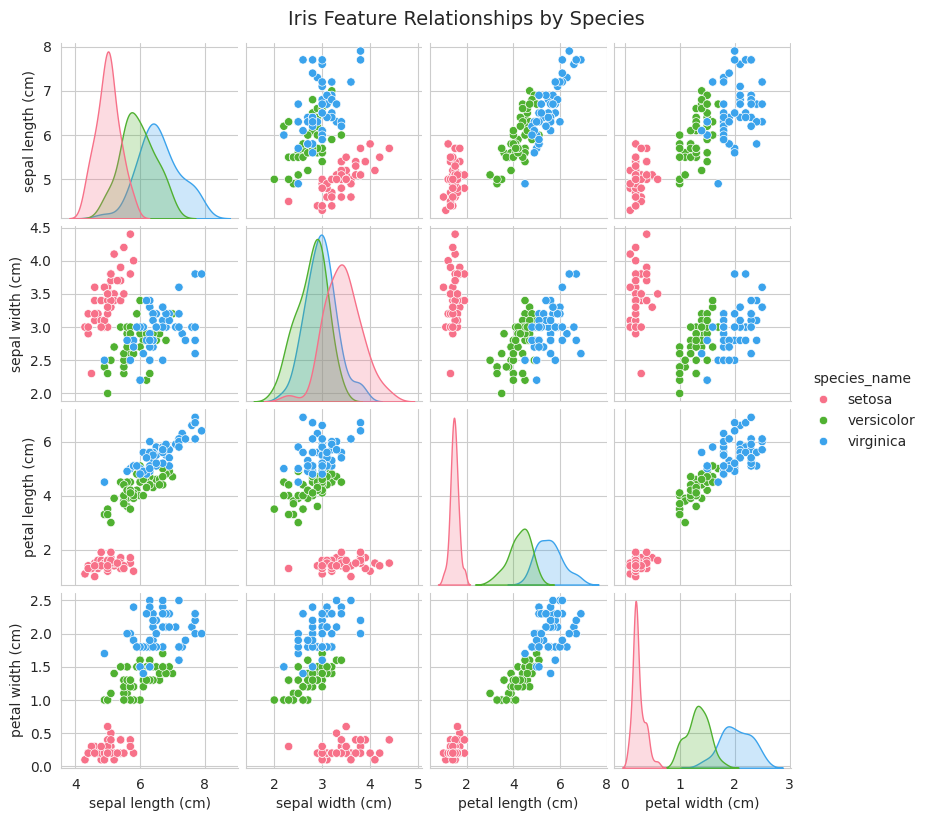


💡 Insight: Petal length/width show clear separation between species!


In [11]:
# Pairplot: the single most valuable EDA tool for small datasets
# Shows relationships between all feature pairs, colored by species
# Note: setosa is clearly linearly separable; others have some overlap
plt.figure(figsize=(10, 8))
pair_plot = sns.pairplot(
    df, 
    hue='species_name',           # Color by species
    vars=iris.feature_names,      # Only plot the 4 feature columns
    diag_kind='kde',              # Kernel density on diagonal
    palette='husl',               # Colorblind-friendly palette
    height=2.0                    # Size of each subplot
)
pair_plot.fig.suptitle('Iris Feature Relationships by Species', y=1.02, fontsize=14)
plt.show()

print("\n💡 Insight: Petal length/width show clear separation between species!")

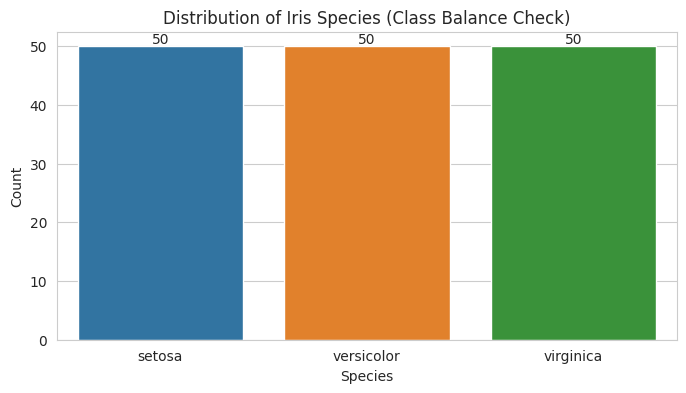

✅ Perfectly balanced classes (50 each) - no need for stratification adjustments


In [12]:
# Class distribution bar plot - always verify balance
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='species_name', hue='species_name')
plt.title('Distribution of Iris Species (Class Balance Check)', fontsize=12)
plt.xlabel('Species')
plt.ylabel('Count')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

print("✅ Perfectly balanced classes (50 each) - no need for stratification adjustments")

## ✂️ 3. Train / Test Split

**Critical concept:** We must evaluate on unseen data. Training on the full dataset and testing on the same data leads to overfitting and worthless metrics.

We use `stratify=y` to ensure our 70/30 split maintains the same class proportions (50/50/50 → 35/35/35 train, 15/15/15 test).

In [13]:
from sklearn.model_selection import train_test_split

# X is the feature matrix (150 samples × 4 features)
X = iris.data
# y is the target vector (150 labels: 0, 1, or 2)
y = iris.target

# Split with stratification to preserve class balance
# random_state=42 ensures reproducibility (same split every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,        # 30% for testing (45 samples), 70% for training (105 samples)
    random_state=42,      # Seed for reproducibility - ALWAYS set this!
    stratify=y            # Maintain class proportions in both splits
)

print("Training set shape:")
print(f"  X_train: {X_train.shape} (features)")
print(f"  y_train: {y_train.shape} (labels)")
print(f"  Class distribution: {np.bincount(y_train)}")

print("\nTest set shape:")
print(f"  X_test: {X_test.shape} (features)")
print(f"  y_test: {y_test.shape} (labels)")
print(f"  Class distribution: {np.bincount(y_test)}")

print("\n✅ Notice the 35/35/35 and 15/15/15 split - stratification working!")

Training set shape:
  X_train: (105, 4) (features)
  y_train: (105,) (labels)
  Class distribution: [35 35 35]

Test set shape:
  X_test: (45, 4) (features)
  y_test: (45,) (labels)
  Class distribution: [15 15 15]

✅ Notice the 35/35/35 and 15/15/15 split - stratification working!


## 🤖 4. Our First Model – Logistic Regression

Despite the name, Logistic Regression is a **classification** algorithm, not regression. Here's what you need to know:

**The Model:**
- Linear model: computes weighted sum of features plus bias
- Sigmoid function $\sigma(z) = \frac{1}{1 + e^{-z}}$ squashes output to probability (0 to 1)
- Decision boundary at 0.5: if $\sigma(z) \geq 0.5$, predict class 1

**Why start here?**
- Fast training, interpretable coefficients
- Provides calibrated probabilities (useful for business decisions)
- Baseline that more complex models must beat

In [14]:
from sklearn.linear_model import LogisticRegression

# Instantiate the model with default parameters
# max_iter=200 ensures convergence on this small dataset (default 100 is sometimes insufficient)
# solver='lbfgs' is the default, robust choice for small datasets
model = LogisticRegression(max_iter=200, random_state=42)

# Fit the model to training data
# This is where the learning happens - optimizing coefficients to minimize loss
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of classes: {model.classes_}")
print(f"Number of features: {model.n_features_in_}")
print(f"Feature names used: {model.feature_names_in_ if hasattr(model, 'feature_names_in_') else 'Not stored (numpy array input)'}")

Model trained successfully!
Number of classes: [0 1 2]
Number of features: 4
Feature names used: Not stored (numpy array input)


In [15]:
# Examine the learned coefficients (model interpretability)
# Shape: (n_classes, n_features) - one set of weights per class
print("Learned coefficients (weights) for each feature per class:")
coef_df = pd.DataFrame(
    model.coef_, 
    columns=iris.feature_names,
    index=[f"Class {i} ({name})" for i, name in enumerate(iris.target_names)]
)
print(coef_df.round(3))

print("\nIntercept (bias) terms:")
for i, (cls, inter) in enumerate(zip(model.classes_, model.intercept_)):
    print(f"  Class {cls}: {inter:.3f}")

print("\n💡 Positive coefficient = feature increases probability of this class")

Learned coefficients (weights) for each feature per class:
                      sepal length (cm)  sepal width (cm)  petal length (cm)  \
Class 0 (setosa)                 -0.545             0.764             -2.229   
Class 1 (versicolor)              0.421            -0.427             -0.100   
Class 2 (virginica)               0.124            -0.337              2.329   

                      petal width (cm)  
Class 0 (setosa)                -0.975  
Class 1 (versicolor)            -0.839  
Class 2 (virginica)              1.813  

Intercept (bias) terms:
  Class 0: 9.928
  Class 1: 2.423
  Class 2: -12.351

💡 Positive coefficient = feature increases probability of this class


## 🎯 5. Predictions & Evaluation

Now for the moment of truth: how well does our model generalize to unseen data?

We'll generate:
- **Hard predictions:** Class labels (0, 1, or 2)
- **Soft predictions:** Probability distributions over classes (useful for uncertainty quantification)

In [16]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Get probability estimates for each class
# Shape: (n_samples, n_classes) - probabilities sum to 1.0 per row
y_proba = model.predict_proba(X_test)

print("Predictions vs Actual (first 10 test samples):")
comparison_df = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred[:10],
    'Actual_Name': [iris.target_names[i] for i in y_test[:10]],
    'Predicted_Name': [iris.target_names[i] for i in y_pred[:10]]
})
print(comparison_df)

print(f"\nProbability estimates for first sample:")
print(f"  Input features: {X_test[0]}")
print(f"  Probabilities: {y_proba[0].round(3)}")
print(f"  Predicted class: {y_pred[0]} (confidence: {y_proba[0].max():.1%})")

Predictions vs Actual (first 10 test samples):
   Actual  Predicted Actual_Name Predicted_Name
0       2          2   virginica      virginica
1       1          1  versicolor     versicolor
2       2          1   virginica     versicolor
3       1          1  versicolor     versicolor
4       2          2   virginica      virginica
5       2          2   virginica      virginica
6       1          1  versicolor     versicolor
7       1          1  versicolor     versicolor
8       0          0      setosa         setosa
9       2          2   virginica      virginica

Probability estimates for first sample:
  Input features: [7.3 2.9 6.3 1.8]
  Probabilities: [0.    0.032 0.968]
  Predicted class: 2 (confidence: 96.8%)


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy: simplest metric - proportion of correct predictions
# On balanced datasets like Iris, accuracy is meaningful
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Correct predictions: {(y_pred == y_test).sum()}/{len(y_test)}")

print("\n" + "="*60 + "\n")

# Classification report: precision, recall, f1-score per class
# Precision: of predicted X, how many were actually X? (avoid false positives)
# Recall: of actual X, how many did we find? (avoid false negatives)
# F1-score: harmonic mean of precision and recall
print("Detailed Classification Report:")
print(classification_report(
    y_test, y_pred, 
    target_names=iris.target_names,
    digits=3
))

Accuracy: 0.933 (93.3%)
Correct predictions: 42/45


Detailed Classification Report:
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.875     0.933     0.903        15
   virginica      0.929     0.867     0.897        15

    accuracy                          0.933        45
   macro avg      0.935     0.933     0.933        45
weighted avg      0.935     0.933     0.933        45



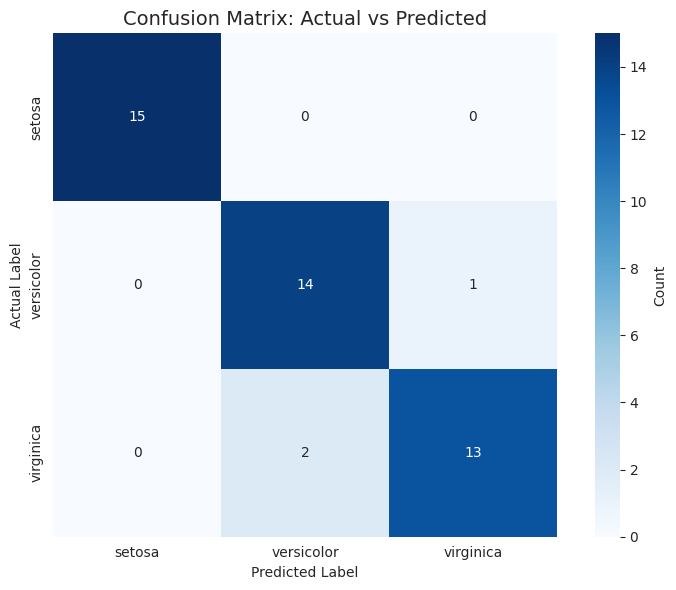


Reading the matrix:
- Diagonal elements: correct predictions
- Off-diagonal: misclassifications
- In this case: 3 total misclassifications


In [18]:
# Confusion Matrix: see exactly where mistakes happen
# Rows = Actual, Columns = Predicted
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,           # Show numbers in cells
    fmt='d',              # Integer format
    cmap='Blues',         # Color scheme
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    square=True,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix: Actual vs Predicted', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

print("\nReading the matrix:")
print("- Diagonal elements: correct predictions")
print("- Off-diagonal: misclassifications")
print(f"- In this case: {(cm - np.diag(np.diag(cm))).sum()} total misclassifications")

## 🗺️ 6. Visualizing Decision Regions

To visualize how Logistic Regression separates classes, we'll:
1. Select the two most discriminative features (petal length & width)
2. Train a new model on just these 2D features
3. Create a meshgrid to evaluate predictions across the entire feature space
4. Plot contour lines showing decision boundaries

In [19]:
# Select the two best features for visualization (indices 2 and 3)
# These showed the clearest separation in our pairplot
X_2d = iris.data[:, [2, 3]]  # petal length, petal width
y = iris.target

# Split the 2D data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y
)

# Train a new model on just 2 features
model_2d = LogisticRegression(max_iter=200)
model_2d.fit(X_train_2d, y_train_2d)

print(f"2D model accuracy: {model_2d.score(X_test_2d, y_test_2d):.3f}")
print("Note: Lower accuracy than 4-feature model - we discarded useful information for visualization")

2D model accuracy: 0.933
Note: Lower accuracy than 4-feature model - we discarded useful information for visualization


In [20]:
# Create a meshgrid to plot decision boundaries
# We need to evaluate the model at every point in the feature space
h = 0.02  # Step size in mesh (smaller = smoother but slower)

# Determine boundaries of our plot
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

# Create coordinate matrices
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Predict class for every point in the mesh
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)  # Reshape back to mesh dimensions

print(f"Meshgrid shape: {xx.shape} - evaluating {xx.size} points")

Meshgrid shape: (170, 345) - evaluating 58650 points


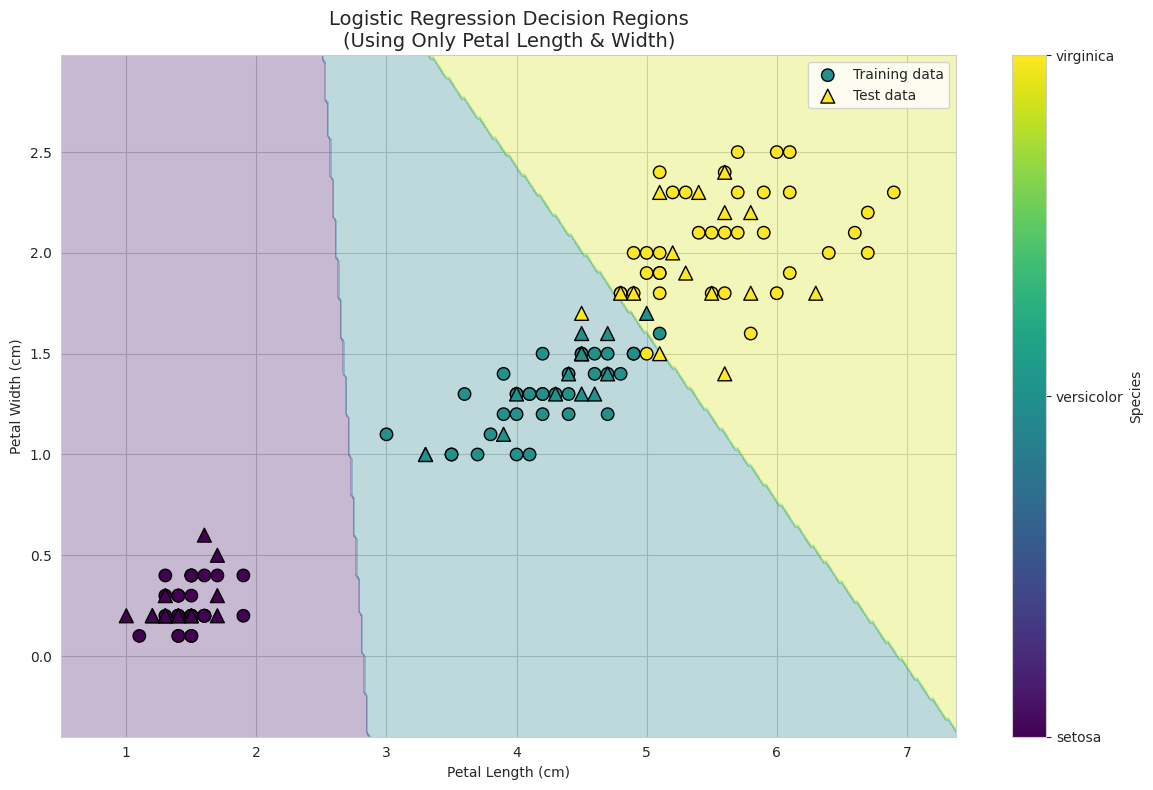


🎯 Interpretation:
- Background colors show where the model would classify new points
- Lines between colors are the decision boundaries
- Notice setosa is perfectly separable (linear boundary)
- Versicolor/virginica have some overlap (expected - they're harder to distinguish)


In [21]:
# Plot the decision boundary
plt.figure(figsize=(12, 8))

# Contour plot: filled regions showing predicted class
contour = plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Scatter plot: actual training points
scatter = plt.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1], 
    c=y_train_2d, edgecolors='k', 
    cmap='viridis', s=80, label='Training data'
)

# Scatter plot: test points with different marker
plt.scatter(
    X_test_2d[:, 0], X_test_2d[:, 1], 
    c=y_test_2d, edgecolors='k', marker='^',
    cmap='viridis', s=100, label='Test data'
)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Logistic Regression Decision Regions\n(Using Only Petal Length & Width)', fontsize=14)
plt.legend()

# Add colorbar with class labels
cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(iris.target_names)
cbar.set_label('Species')

plt.tight_layout()
plt.show()

print("\n🎯 Interpretation:")
print("- Background colors show where the model would classify new points")
print("- Lines between colors are the decision boundaries")
print("- Notice setosa is perfectly separable (linear boundary)")
print("- Versicolor/virginica have some overlap (expected - they're harder to distinguish)")

## ⚠️ Common Mistakes New ML Practitioners Make + Pro Tips

Even experienced Python developers stumble when transitioning to ML. Here are the critical gotchas:

**1. Ignoring `random_state`** 🎲
- *Mistake:* Not setting random seeds → irreproducible results across runs
- *Fix:* Always set `random_state=42` (or any integer) in `train_test_split`, model initialization, and cross-validation
- *Why:* Science demands reproducibility; debugging is impossible with random variations

**2. Data Leakage Between Splits** 💧
- *Mistake:* Fitting scalers/imputers on the full dataset before splitting
- *Fix:* Fit preprocessing steps **only** on training data, then transform both sets
- *Example:* `scaler.fit(X_train); X_train_scaled = scaler.transform(X_train); X_test_scaled = scaler.transform(X_test)`

**3. Assuming All Models Need Scaling** 📏
- *Mistake:* Blindly applying StandardScaler to every algorithm
- *Reality:* Tree-based models (Random Forest, XGBoost) are scale-invariant; linear models (SVM, Logistic Regression, Neural Nets) require scaling
- *Fix:* Check algorithm documentation—scaling unnecessary for trees, essential for distance-based methods

**4. Evaluating on Training Data** 🚨
- *Mistake:* `model.fit(X, y); predictions = model.predict(X); accuracy_score(y, predictions)`
- *Result:* Misleadingly high accuracy (overfitting); fails to detect generalization failure
- *Fix:* Strict separation: train on training set, final evaluation **only** on test set

**5. Ignoring Class Imbalance** ⚖️
- *Mistake:* Using accuracy on imbalanced data (99% negatives, 1% positives → 99% accuracy by predicting all negative)
- *Fix:* Use stratification in splits; evaluate with F1-score, precision-recall curves, or balanced accuracy
- *Advanced:* Consider SMOTE, class weights, or threshold tuning

**6. Not Checking for Missing Values/Outliers** 🔍
- *Mistake:* Feeding raw data with NaNs or extreme outliers into models
- *Fix:* Always run `df.isnull().sum()` and visualize distributions before modeling
- *Note:* Iris is clean by design; real data is messy

**7. Overfitting to the Test Set** 🔄
- *Mistake:* Repeatedly tweaking model hyperparameters based on test set performance
- *Result:* Test set becomes part of training (indirect overfitting); real-world performance disappoints
- *Fix:* Use validation set or cross-validation for tuning; touch test set **only once** at the very end

## 🏋️ Exercises

Test your understanding with these progressively challenging exercises:

### Exercise 1: Easy – Try a Different Algorithm
Replace Logistic Regression with `DecisionTreeClassifier` (from `sklearn.tree`).
- Train it on the same Iris train/test split
- Compare accuracy to Logistic Regression
- Visualize the tree using `plot_tree` from `sklearn.tree`
- *Question:* Does it perform better or worse? Why might trees overfit on small datasets?

### Exercise 2: Medium – New Dataset
Use the Wine dataset (`load_wine` from `sklearn.datasets`) instead of Iris.
- It has 3 classes and 13 features (more complex!)
- Perform the same EDA and train/test split
- Train Logistic Regression and evaluate with classification report
- *Challenge:* The features have different scales—should you scale them?

### Exercise 3: Medium-Hard – Model Comparison
Compare 3 algorithms side-by-side on Iris:
1. Logistic Regression (baseline)
2. K-Nearest Neighbors (`KNeighborsClassifier`, try k=5)
3. Random Forest (`RandomForestClassifier`, n_estimators=100)

For each, report:
- Accuracy
- F1-score (macro average)
- Training time (use `time.time()`)

Create a summary DataFrame ranking the models. Which is best for this dataset?

### Exercise 4: Hard – Generic Training Function
Write a reusable function `train_and_evaluate(dataset_loader, model, test_size=0.3)` that:
- Accepts any sklearn dataset loader function (e.g., `load_iris`, `load_wine`, `load_breast_cancer`)
- Accepts any instantiated sklearn model
- Performs stratified train/test split
- Trains the model
- Returns a dictionary with: `accuracy`, `f1_score`, `training_time`, `predictions`, `probabilities`

Test your function on at least 3 different datasets with 2 different models each.
*Hint:* Use `isinstance` checks to handle datasets with/without `feature_names` attributes gracefully.

<details>
<summary>📝 Click to view Exercise Solutions (try them first!)</summary>

### Exercise 1 Solution: Decision Tree

```python
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.3f}")
print(f"Logistic Regression Accuracy: {accuracy:.3f}")

# Visualize
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()
```

### Exercise 2 Solution: Wine Dataset

```python
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# Note: Wine features are on different scales (e.g., alcohol % vs magnesium content)
# Scaling IS recommended here!
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

# Scale the data
scaler = StandardScaler()
X_train_w_scaled = scaler.fit_transform(X_train_w)
X_test_w_scaled = scaler.transform(X_test_w)

model_wine = LogisticRegression(max_iter=1000)
model_wine.fit(X_train_w_scaled, y_train_w)
print(classification_report(y_test_w, model_wine.predict(X_test_w_scaled), target_names=wine.target_names))
```

### Exercise 3 Solution: Model Comparison

```python
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')
    
    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'Time (s)': train_time})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df)
```

### Exercise 4 Solution: Generic Function

```python
def train_and_evaluate(dataset_loader, model, test_size=0.3):
    """Generic training and evaluation function for sklearn datasets."""
    import time
    from sklearn.metrics import f1_score
    
    # Load data
    data = dataset_loader()
    X, y = data.data, data.target
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # Train
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Predict
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    # Metrics
    return {
        'accuracy': accuracy_score(y_test, predictions),
        'f1_score': f1_score(y_test, predictions, average='macro'),
        'training_time': train_time,
        'predictions': predictions,
        'probabilities': probabilities
    }

# Test it
from sklearn.datasets import load_breast_cancer
print("Iris + LogReg:", train_and_evaluate(load_iris, LogisticRegression(max_iter=200))['accuracy'])
print("Wine + RF:", train_and_evaluate(load_wine, RandomForestClassifier(random_state=42))['accuracy'])
print("Cancer + KNN:", train_and_evaluate(load_breast_cancer, KNeighborsClassifier())['accuracy'])
```

</details>

## 🎓 Summary – What You Learned Today

Congratulations on completing your first machine learning notebook! Here's what you've mastered:

✅ **Core Concepts**
- The difference between traditional programming (rules → data → answers) and ML (data + answers → rules)
- The three types of ML: supervised, unsupervised, and reinforcement learning
- Classification vs. regression: predicting discrete labels vs. continuous values

✅ **Practical Skills**
- Loading and inspecting sklearn datasets (the foundation of most ML workflows)
- Exploratory Data Analysis using seaborn pairplots to assess class separability
- Proper train/test splitting with stratification to maintain class balance
- Building, training, and evaluating your first model (Logistic Regression)
- Interpreting classification metrics: accuracy, precision, recall, F1-score, and confusion matrices
- Visualizing decision boundaries to understand how models separate classes

✅ **Professional Practices**
- Always set `random_state` for reproducibility
- Never evaluate on training data (the overfitting trap)
- Check class balance before choosing evaluation metrics
- Understand when feature scaling is necessary (linear models: yes; trees: no)

---


**Auther!** Tassawar Abbas  
**Email:** abbas829@gmail.com